This notebook explores the impact of AI on Students dataset containing 50k student records. This analysis is driven by 3 main questions: 1- Are  weekly AI usage and GPA correlated in anyway. 2- Does the primary reason for the students usage of AI matter when it comes to changes in GPA, skill retention, and perceived AI dependence. 3- Does AI use for more skill based reasons such as debugging or troubleshooting affect a students skill retention more than other heavy uses. The working hypothesis was that AI usage would clearly harm academic outcomes, the data was more nuanced than expected.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df = pd.read_csv("ai_student_impact_dataset.csv")
print(df.isnull().sum())

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64


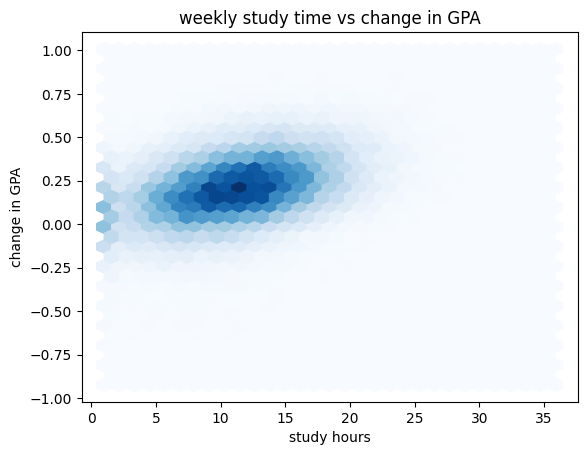

In [3]:
df["GPA_change"]= df["Post_Semester_GPA"]- df["Pre_Semester_GPA"]
plt.hexbin(df["Traditional_Study_Hours"],df["GPA_change"], gridsize=30 , cmap="Blues")
plt.xlabel("study hours")
plt.ylabel("change in GPA")
plt.title("weekly study time vs change in GPA")
plt.show()

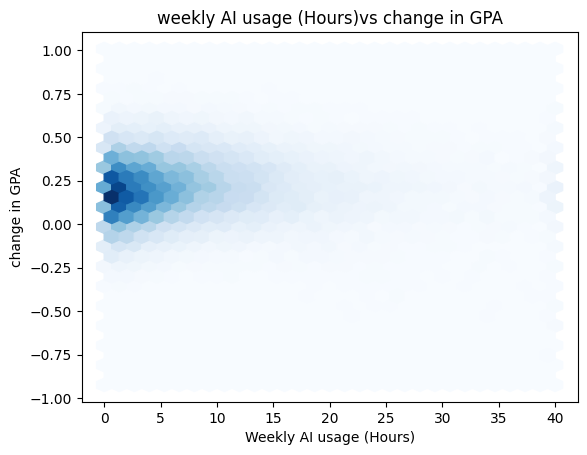

In [4]:
plt.hexbin(df["Weekly_GenAI_Hours"],df["GPA_change"], gridsize=30 , cmap="Blues")
plt.xlabel("Weekly AI usage (Hours)")
plt.ylabel("change in GPA")
plt.title("weekly AI usage (Hours)vs change in GPA")
plt.show()

In the previous 2 cells I made 2 Hexbin plots. The first plot compare weekly study hours to the change in GPA(post_semester - pre_semester) there is a clear upwards shift in the data along the x-axis suggesting that the increase in weekly study hours does in fact have a positive effect on a students GPA. In the second hexbin plot I compared weekly AI usage to the change GPA, the plot showed no clear shift neither up nor down suggesting that an increase in weekly AI usage doesnt seem to have a real effect on a students GPA be it negatively or positively.

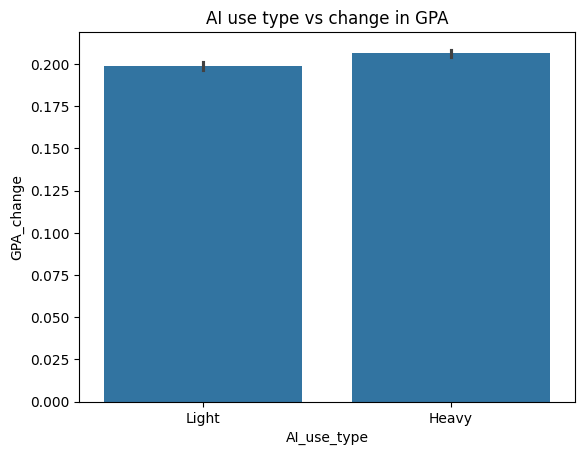

In [5]:
light_use_case=["Summarizing_Reading","Copywriting/Drafting"]
heavy_use_case=["Ideation","Direct_Answer_Generation"]
df["AI_use_type"]=df["Primary_Use_Case"].apply(lambda x: "Light" if x in light_use_case else "Heavy")

sb.barplot(data=df , x="AI_use_type", y="GPA_change" , estimator='mean')
plt.title("AI use type vs change in GPA")
plt.show()

In the previous cell I separated AI use cases into light and heavy categories according to how much of the work the AI agent is doing in the students place. For the light category I included summarization, and drafting. For the heavy category I included Ideation, and direct answer generation. The plot shows a surprising outcome which suggests that heavy use case students had a slightly superior change in GPA when compared to light use case students. One possible explanation is that the heavy use case students were strategic about their studying, but without any data about academic integrity no stronger conclusions can be derived.

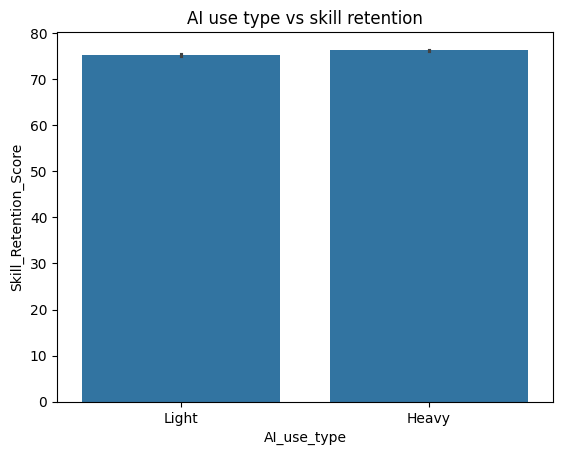

In [6]:
sb.barplot(data=df , x="AI_use_type", y="Skill_Retention_Score" , estimator='mean')
plt.title("AI use type vs skill retention")
plt.show()

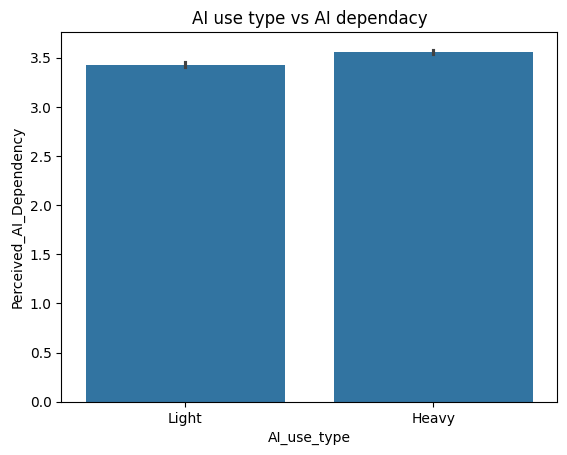

In [7]:
sb.barplot(data=df , x="AI_use_type", y="Perceived_AI_Dependency" , estimator='mean')
plt.title("AI use type vs AI dependacy")
plt.show()

In the 2 previous cells I once again compared the light and heavy use case categories to eachother, in the first cell I compared them according to the students skill retention score, in the second cell I compared them according to the students perceived AI dependency. The first cells barplot is most surprising as it suggests that heavy use case students had a skill retention score that was superior but only by a fraction. The second cells barplot suggests that both heavy and light users feel slightly dependant on AI with both groups having a similar score of about 
3.5/10 with light users coming just short of it suggesting neither group feels strongly dependent on AI. 

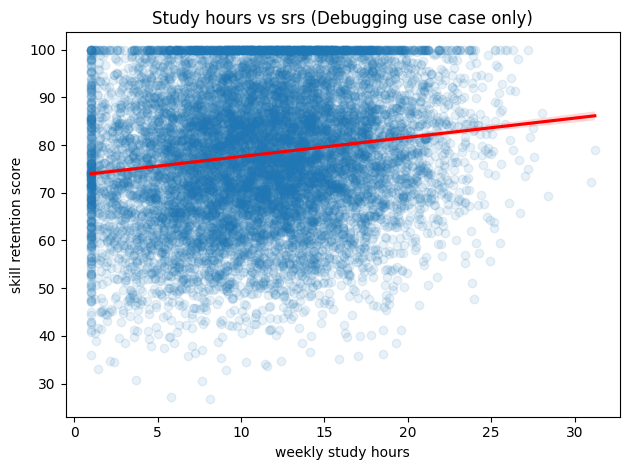

In [8]:
filtered_df= df.loc[df["Primary_Use_Case"]=="Debugging/Troubleshooting"]
sb.regplot(data=filtered_df,x="Traditional_Study_Hours", y="Skill_Retention_Score",scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.xlabel("weekly study hours")
plt.ylabel("skill retention score")
plt.title("Study hours vs srs (Debugging use case only)")
plt.tight_layout()
plt.show()

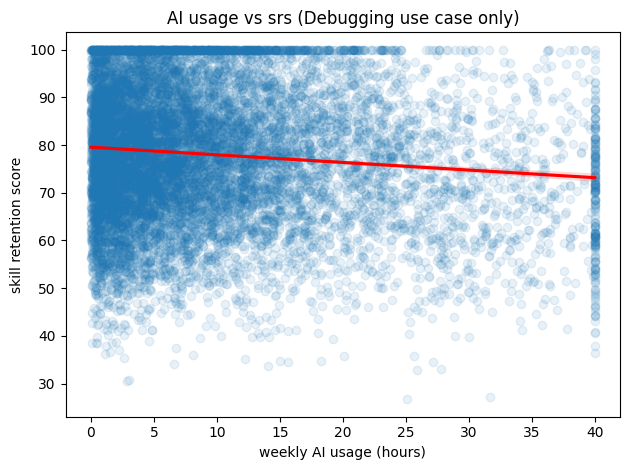

In [9]:
sb.regplot(data=filtered_df,x="Weekly_GenAI_Hours", y="Skill_Retention_Score",scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.xlabel("weekly AI usage (hours)")
plt.ylabel("skill retention score")
plt.title("AI usage vs srs (Debugging use case only)")
plt.tight_layout()
plt.show()

In the previous 2 cells I filtered the dataset to only include students who reported Debugging/Troubleshooting as their primary AI use case. The first plot compared their study hours against their skill retention score, showing a clear positive trend. The second plot compared their weekly AI usage against skill retention, showing a slight negative trend suggesting that even within a task specific use case like debugging, heavier AI usage is associated with lower skill retention over time. This implies that while debugging tools can be a legitimate aid, over reliance on them may quietly erode the problem solving ability they are meant to support.

At first I had set out to use this analysis to prove that AI usage would have a clear negative effect on a person's academic performance regardless of what their usage was like. Question 1 was pretty surprising as it showed that an increase in the volume of AI usage had almost no effect on the students GPA, positive or negative. Questions 2 was extremely surprising, after splitting the students primary use cases (excluding debugging) into 2 categories one being heavy and the other being light and comparing them according to the metrics I mentioned in the introduction the outcome suggests that the students with heavy primary use cases seem to be doing very slightly better in almost every metric. In question 3 after comparing debugging use case students' skill retention score to their study hours then their weekly AI usage, the data suggested a negative trend as AI usage increased which makes sense as debugging is a skill unlike all other use cases within this dataset.


-It is worth noting that key metrics such as skill retention and AI dependency are self-reported, and the absence of any academic integrity data means stronger conclusions cannot be drawn from the question 2's findings.